In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip
from qutip import *
from qutip import about, basis, destroy, mesolve, ptrace, qeye, tensor, wigner
import math
%matplotlib inline

In [27]:
hbar = 1
omegac = 2*np.pi*312.5*10**(3) # field frequency
omega0 = omegac # transition frequency
Omega = 2*np.pi*15.625*10**(3) # coupling strength
N = 100  # number of cavity fock states
tlist = np.linspace(0, 250*10**(-6), 2501) # Time interval and time steps

In [38]:
# intial state
#psi0 = tensor(basis(2,1), 1/2*(coherent(N,0)+coherent(N,1))) 
psi0 = tensor(basis(2,1), coherent(N,5)) 
psi0_B = tensor(basis(2,0), coherent(N,0.32*(np.sqrt(2)/2+1j*np.sqrt(2)/2)))
psi0_C = tensor(basis(2,0), coherent(N,0.32*1j))  
#psi0 = tensor(basis(2,0), coherent(N,-5-1j) + coherent(N,5+1j))

#coherent_state = 0
#for i in range(N):
#    coherent_state += basis(N,i)

#print(coherent_state)
#psi0 = tensor(basis(2,0), coherent_state)
#print(psi0)

# operators
#sigma-minus operators operating on the atomic state and the motional state of two qubits
sm = 1/2*(sigmax()-1j*sigmay())
sm1 = tensor(sm, qeye(N))
#sigmaz operators 
sx1 = tensor(sigmax(), qeye(N))
sy1 = tensor(sigmay(), qeye(N))
sz1 = tensor(sigmaz(), qeye(N))
#annihilation operators
a = tensor(qeye(2), destroy(N))

In [34]:
# These are used to define the time-dependent part of the Hamiltonian
def h_1(t, args=None):
    return np.exp(1j*(-omegac+omega0)*t)

def h_2(t, args=None):
    return np.exp(-1j*(-omegac+omega0)*t)

In [39]:
# Time-independent part of the Hamiltonian
H_af = hbar * Omega * (a * sm1.dag() + a.dag() * sm1)
H_a = hbar * omega0 * sz1/2
H_f = hbar * omegac * a.dag()*a
H = H_a + H_f + H_af

# Standard QuTiP format to combine the time-dependent and time-independent part
# For example, [H_r1o1_1, h_tr1d1], the first one is the time-independent part and the second one is the time-dependet part.The order cannot be reversed in this []
#H = [[H_1, h_1], [H_2, h_2]]
output = mesolve(H, psi0, tlist, [], [])
output2 = mesolve(H, psi0_B, tlist, [], [])
output3 = mesolve(H, psi0_C, tlist, [], [])

In [10]:
H_test = hbar * omegac * create(N) * destroy(N)
output = mesolve(H_test, coherent(N,1)*coherent(N,1).dag(),tlist,[],[])

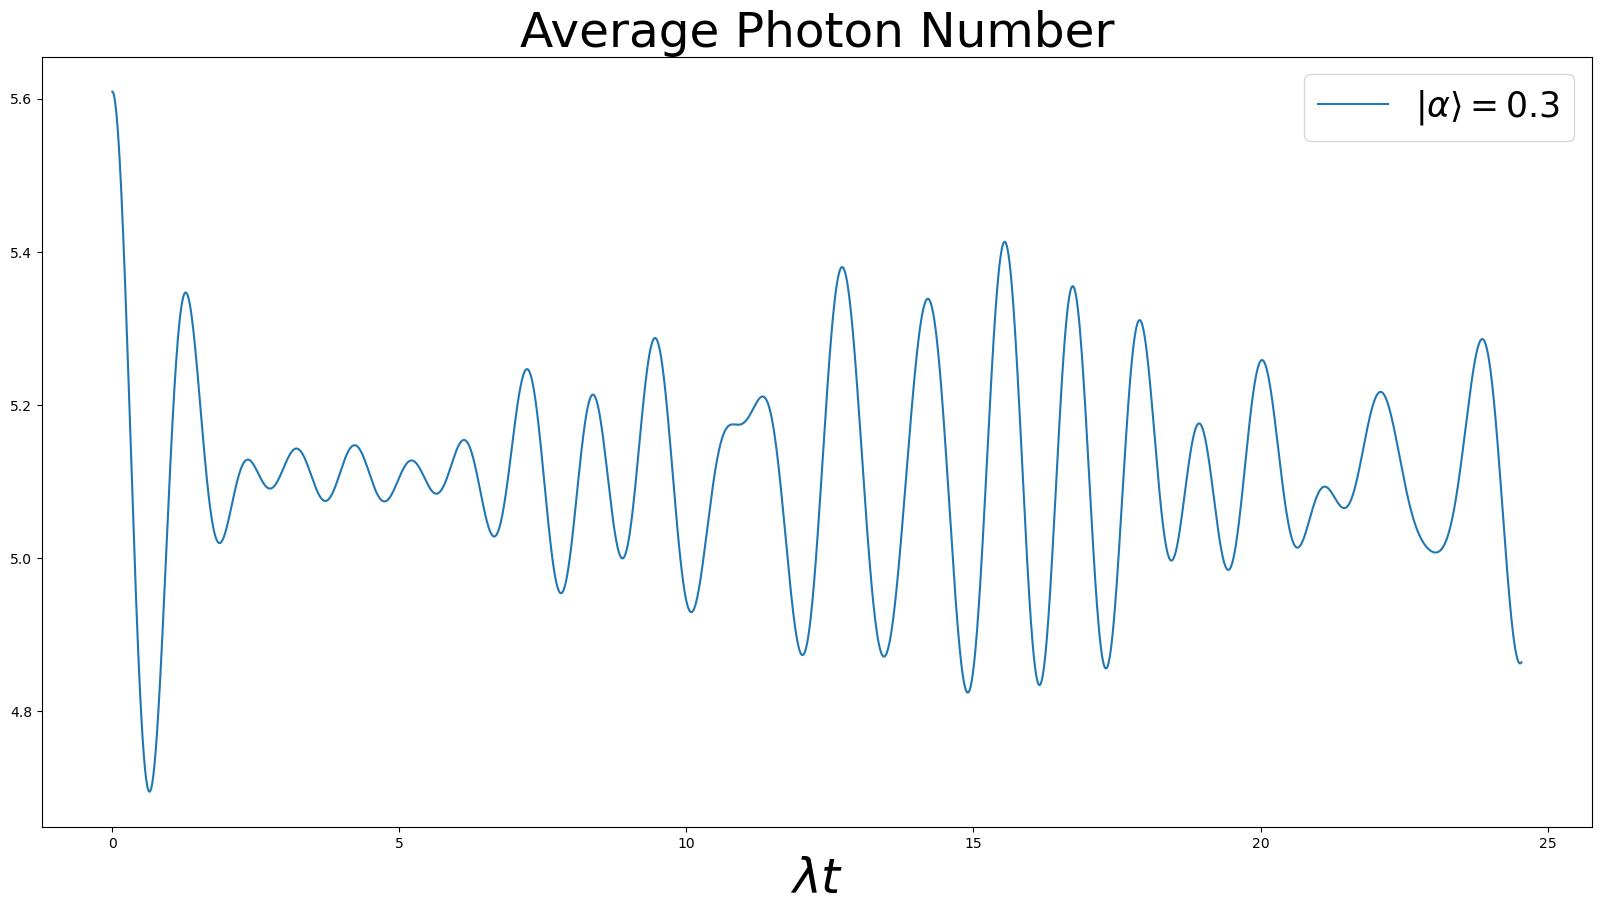

In [6]:
n_a = expect(a.dag()*a, output.states)
tlist2 = np.linspace(0,250*10**(-6)*Omega,2501) # Change the unit of x-axis into microsecond

fig, axes = plt.subplots(1, 1, figsize=(20, 10))
axes.plot(tlist2, n_a, label=r'$|\alpha \rangle=0.3$')
axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
#axes.set_ylabel("Fidelity", fontsize = 35)
axes.set_title("Average Photon Number", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [37]:
def poisson_eq(N,alpha):
    sum_1 = 0
    for i in range(N):
        sum_1 += alpha**(2*i)/math.factorial(i)
    sum_1 = np.exp(-alpha**2)*sum_1
    return sum_1

test_aaa = poisson_eq(10,0.3)
print(test_aaa)

1.0000000000000002


24.551961061965883


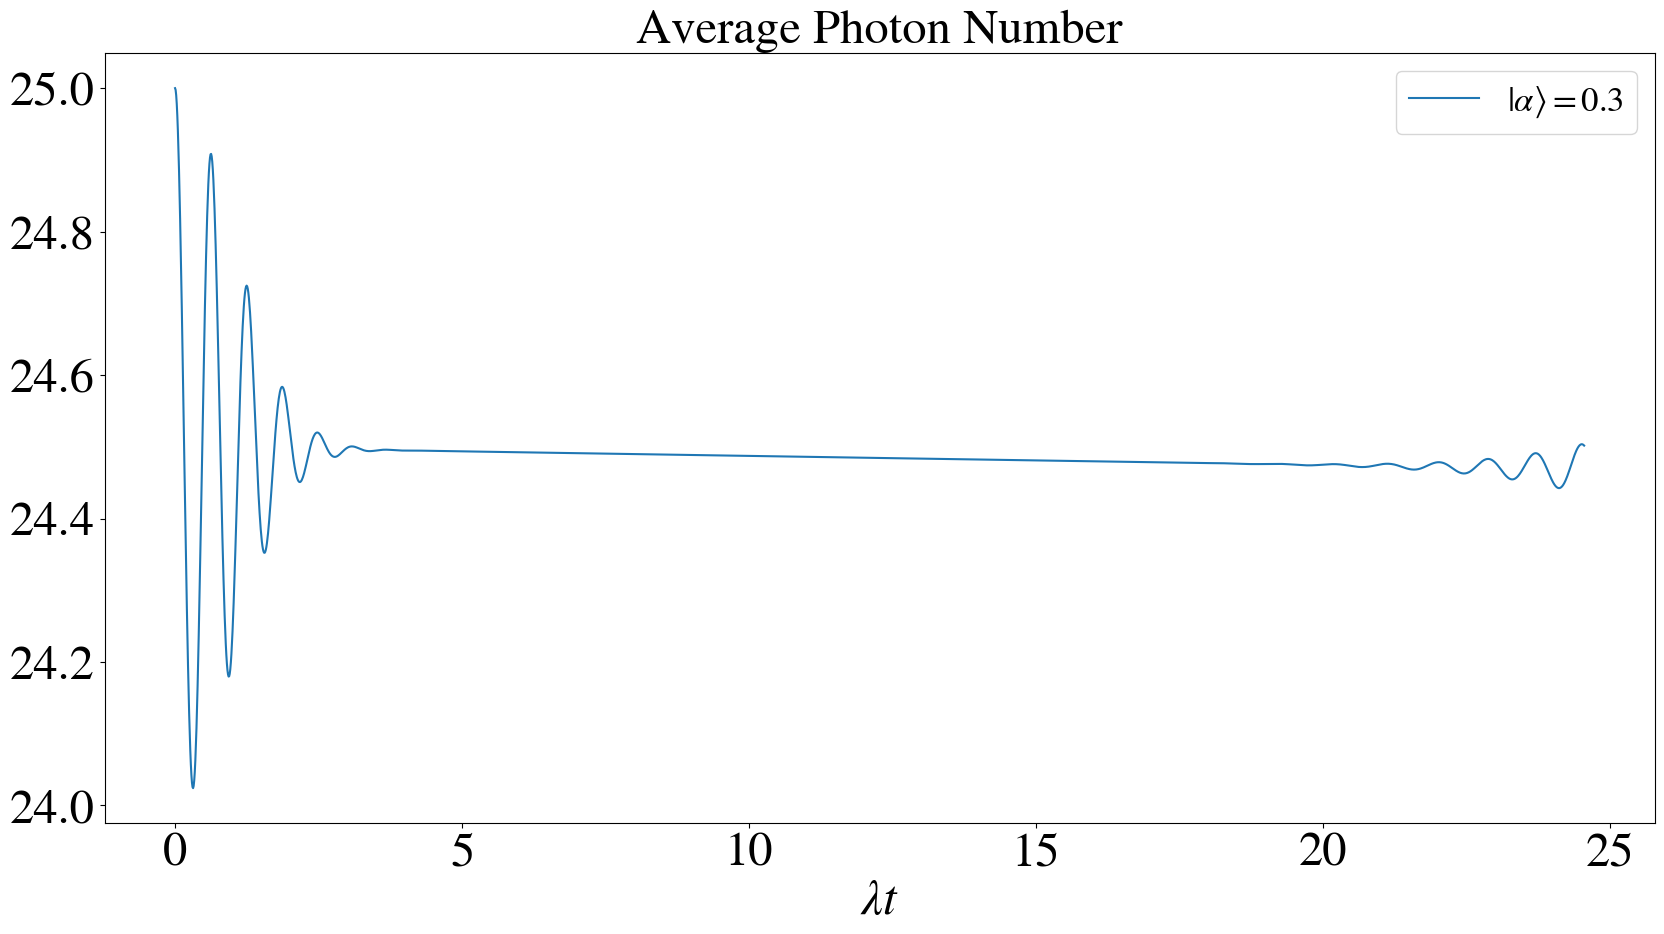

In [40]:
#n_a = expect(tensor(basis(2,0), coherent(N,2))*tensor(basis(2,0), coherent(N,2)).dag(), output.states)
n_a = expect(a.dag() * a, output.states)
#n_a2 = expect(a.dag() * a, output2.states)
#n_b = expect(sm1.dag() * sm1, output.states)

print(n_a[15])

fig, axes = plt.subplots(1, 1, figsize=(20, 10))

import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,          # No LaTeX needed
    "font.family": "serif",
    "mathtext.fontset": "stix",     # Uses the STIX math font
    "font.serif": ["STIXGeneral"],  # Uses the STIX text font
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})



tlist2 = np.linspace(0,250*10**(-6)*Omega,2501) # Change the unit of x-axis into microsecond

axes.plot(tlist2, n_a, label=r'$|\alpha \rangle=0.3$')
#axes.plot(tlist2, n_a2, label=r'$|\alpha \rangle=0.3*(\frac{\sqrt{2}}{2}+\frac{\sqrt{2}i}{2})$')
#axes.plot(tlist2, n_c, label=r'$<ge>+<eg>$',color = 'green')
axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
#axes.set_ylabel("Fidelity", fontsize = 35)
axes.set_title("Average Photon Number", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [41]:
#output1.states
density_matrix_A = []
reduced_density_matrix_A_1 = []
reduced_density_matrix_A_2 = []
for i in range(len(tlist)):
    density_matrixA = output.states[i]*output.states[i].dag()
    density_matrix_A.append(density_matrixA)
    reduced_density_matrix_A_1.append(density_matrixA.ptrace([0]))
    reduced_density_matrix_A_2.append(density_matrixA.ptrace([1]))

density_matrix_B = []
reduced_density_matrix_B_1 = []
reduced_density_matrix_B_2 = []
for i in range(len(tlist)):
    density_matrixB = output2.states[i]*output2.states[i].dag()
    density_matrix_B.append(density_matrixB)
    reduced_density_matrix_B_1.append(density_matrixB.ptrace([0]))
    reduced_density_matrix_B_2.append(density_matrixB.ptrace([1]))

density_matrix_C = []
reduced_density_matrix_C_1 = []
reduced_density_matrix_C_2 = []
for i in range(len(tlist)):
    density_matrixC = output3.states[i]*output3.states[i].dag()
    density_matrix_C.append(density_matrixC)
    reduced_density_matrix_C_1.append(density_matrixC.ptrace([0]))
    reduced_density_matrix_C_2.append(density_matrixC.ptrace([1]))

32
0.11331763754012016


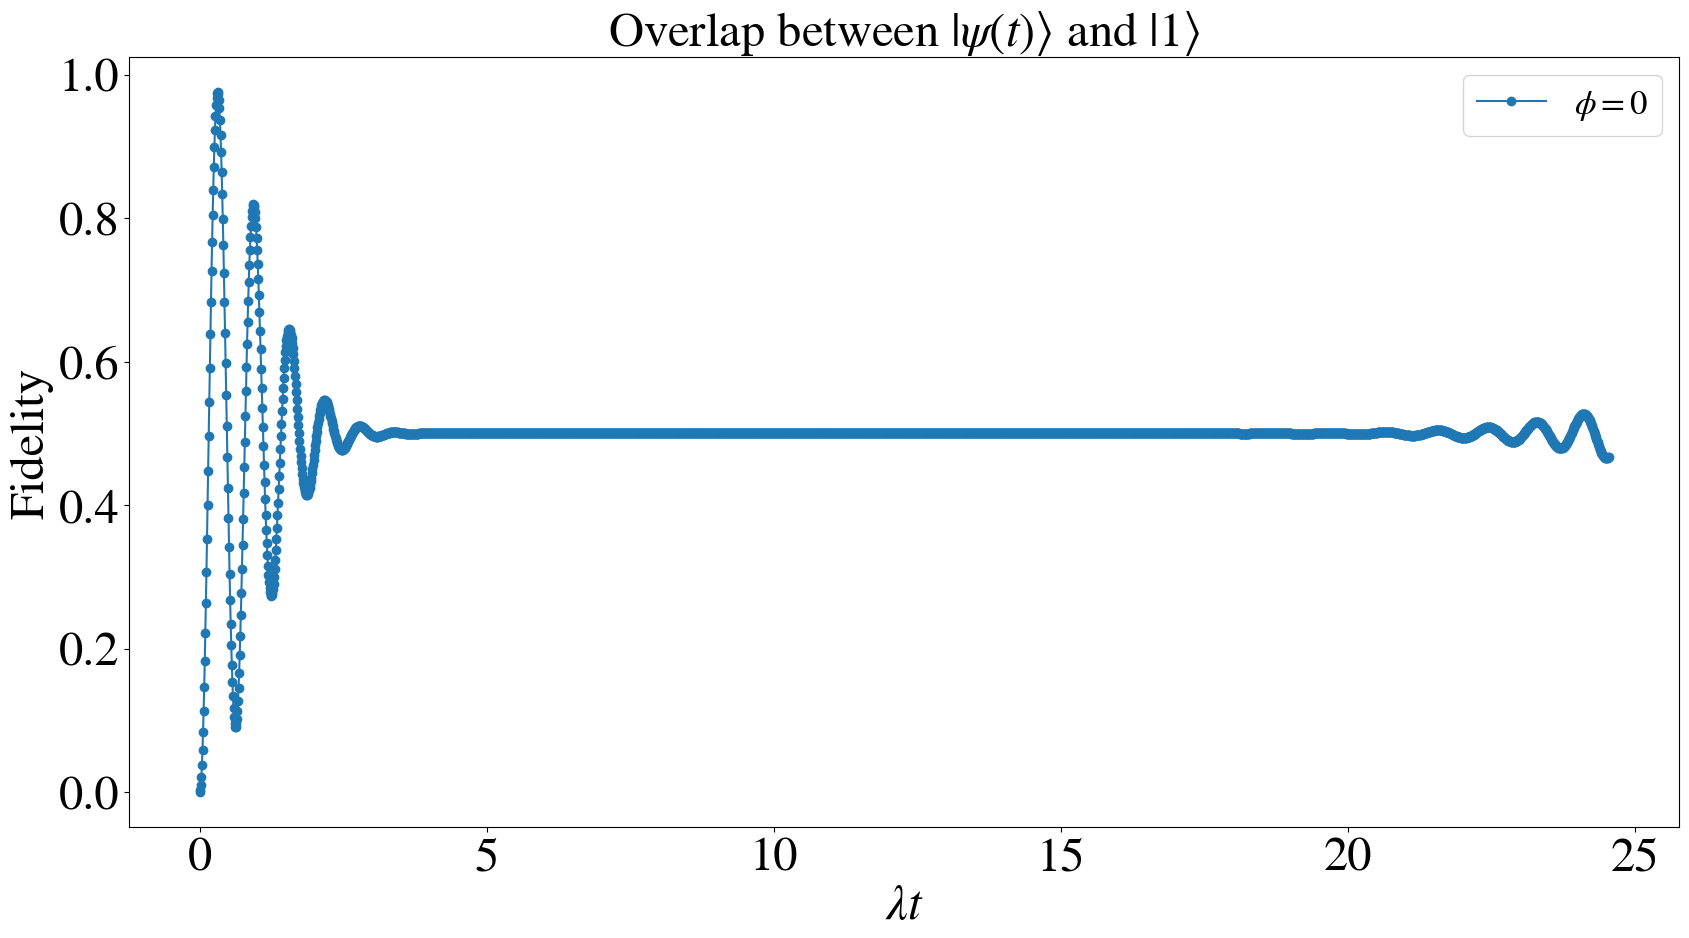

In [42]:
n_b = []
n_b2 = []
n_b3 = []
for i in range(len(tlist)):
    n_b.append(expect(reduced_density_matrix_A_1[i], basis(2,0)))
    n_b2.append(expect(reduced_density_matrix_B_1[i], basis(2,1)))
    n_b3.append(expect(reduced_density_matrix_C_1[i], basis(2,1)))

max_index = n_b.index(max(n_b))
print(max_index)
#print(n_b)
print(n_b[7])
#print(n_b.index(0.9963261370685562))
#print(tlist2[80])
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

#tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, n_b, label=r'$\phi=0$', linestyle='-', marker='o')
#axes.plot(tlist2, n_b2, label=r'$\phi=\pi/4$', linestyle='--')
#axes.plot(tlist2, n_b3, label=r'$\phi=\pi/2$', linestyle=':')
axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
axes.set_ylabel("Fidelity", fontsize = 35)
axes.set_title(r'Overlap between $|\psi(t)\rangle$ and $|1\rangle$', fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [43]:
print(max(n_b))

0.9755041027169642


In [85]:
# Convert lists to a 2D NumPy array
data = np.column_stack((tlist2, n_b, n_b2, n_b3))

# Save as CSV (use comma delimiter)
np.savetxt("fidelity_data.csv", data, delimiter=",", header="t,fidelity1,fidelity2,fidelity3", comments='')

# Or save as DAT (space-delimited)
np.savetxt("fidelity_data.dat", data, delimiter=" ", header="t fidelity1 fidelity2 fidelity3", comments='')

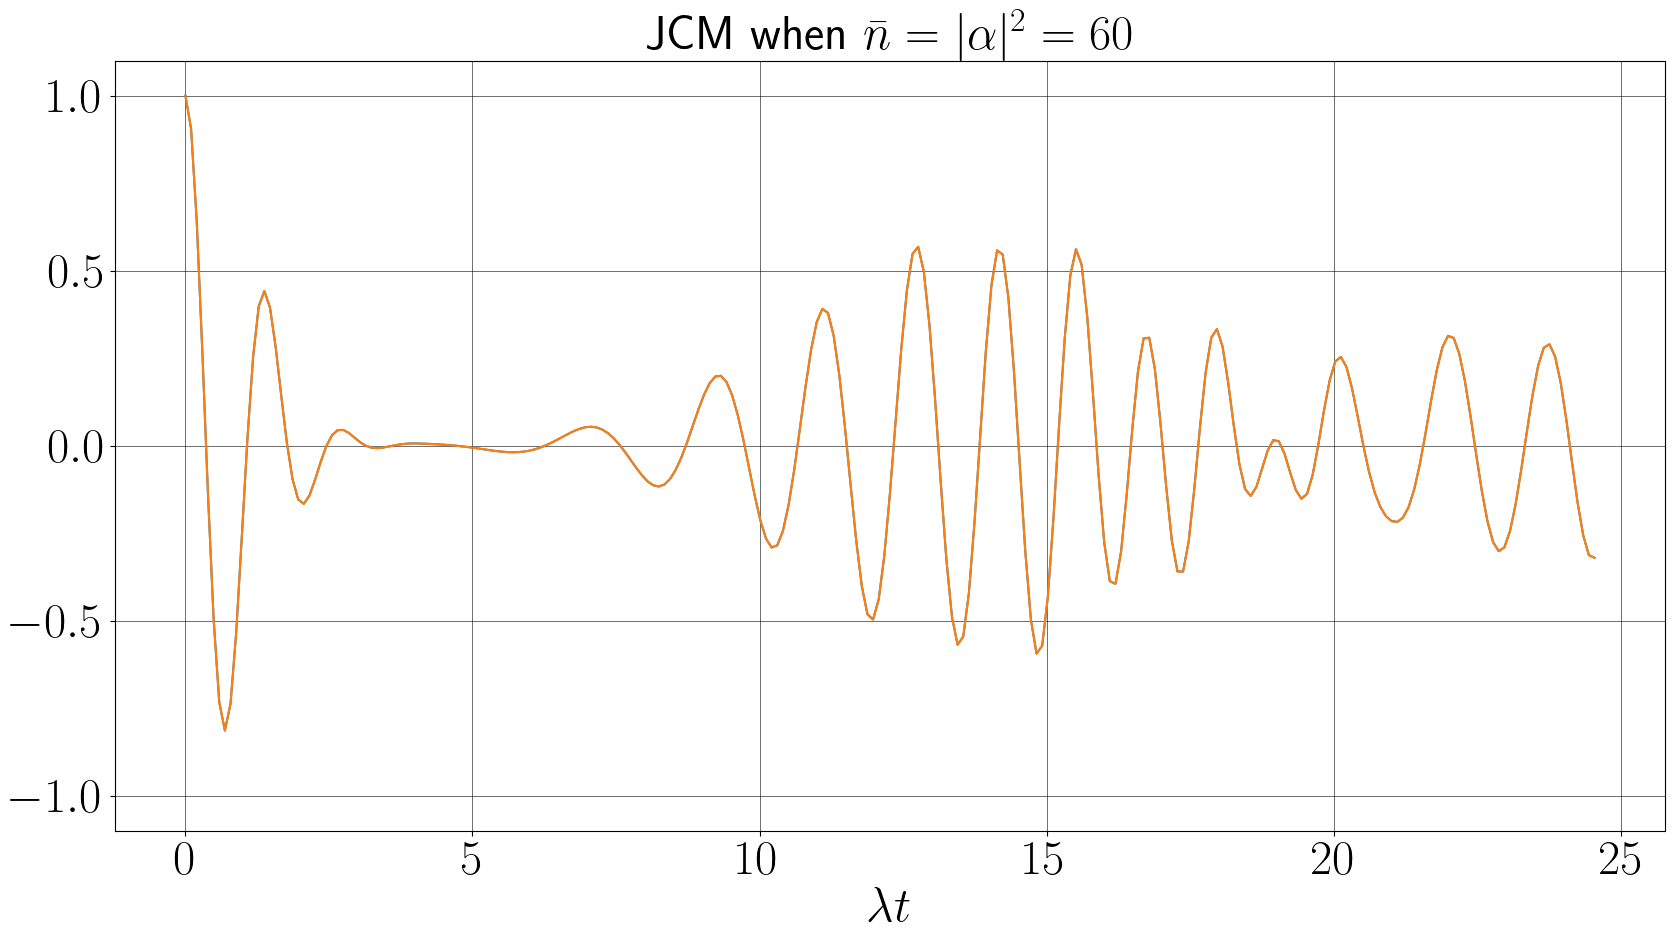

In [31]:
#b.clear()
n_c = expect(sx1,output.states)
n_c2 = expect(sx1, output2.states)
n_d = expect(sy1,output.states)
n_d2 = expect(sy1, output2.states)
n_e = expect(sz1,output.states)
n_e2 = expect(sz1, output2.states)
#n_a = expect(tensor(basis(2,0), coherent(N,0))*tensor(basis(2,0), coherent(N,0)).dag(), output.states)
#n_b = expect(tensor(basis(2,1), coherent(N,0))*tensor(basis(2,1), coherent(N,0)).dag(), output.states)
#n_b = 0
#for i in range(N):
#    n_b += expect(tensor(basis(2,0), coherent(N,i))*tensor(basis(2,1), coherent(N,i)).dag(), output.states)

fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, n_e, label=r'$<g,0>$')
axes.plot(tlist2, n_e2, label=r'$<e,0>$')
#axes.plot(tlist2, n_c, label=r'$<ge>+<eg>$',color = 'green')
#axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
#axes.set_ylabel("Atomic Inversion", fontsize = 35)
axes.set_title(r'JCM when $\bar{n} = |\alpha|^2 =60$', fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
plt.grid(color='black', linestyle='-', linewidth=0.4)
plt.ylim(-1.1,1.1)
plt.show()

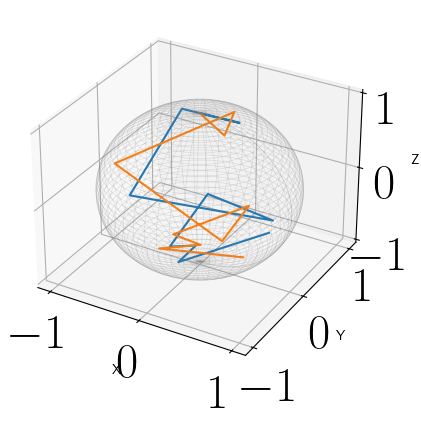

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot(n_c[:10],n_d[:10],n_e[:10])
ax.plot(n_c2[:10],n_d2[:10],n_e2[:10])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot_wireframe(x, y, z, color='gray', alpha=0.2, linewidth=0.5)

plt.show()

In [197]:
eigenvalues_A = np.linalg.eigvalsh(reduced_density_matrix_A_1[770].full())
eigenvalues_B = np.linalg.eigvalsh(reduced_density_matrix_B_1[770].full())
print(eigenvalues_A, eigenvalues_B)

[0.00328425 0.99671575] [0.00328425 0.99671575]


In [17]:
#print(output.states[1].full())
#A = output.states[0] * output.states[0].dag()
#B = A.ptrace([0])
#eigenvalues = np.linalg.eigvalsh(B.full())
#entropy = -np.sum(eigenvalues * np.log2(eigenvalues + 1e-10))

#print(entropy)

systemA_entropy = []
systemB_entropy = []
systemAB_entropy = []

for i in range(len(tlist)):
    density_matrix = output.states[i] * output.states[i].dag()
    reduced_density_matrix_A = density_matrix.ptrace([0])
    reduced_density_matrix_B = density_matrix.ptrace([1])
    eigenvalues_A = np.linalg.eigvalsh(reduced_density_matrix_A.full())
    eigenvalues_B = np.linalg.eigvalsh(reduced_density_matrix_B.full())
    eigenvalues_AB = np.linalg.eigvalsh(density_matrix.full())
    #print(eigenvalues_A,eigenvalues_B)
    entropy_A = -np.sum(eigenvalues_A * np.log2(eigenvalues_A + 1e-10))
    entropy_B = -np.sum(eigenvalues_B * np.log2(eigenvalues_B + 1e-10))
    entropy_AB = -np.sum(eigenvalues_AB * np.log2(eigenvalues_AB + 1e-10))
    systemA_entropy.append(entropy_A)
    systemB_entropy.append(entropy_B)
    systemAB_entropy.append(entropy_AB)
#print(systemA_entropy)

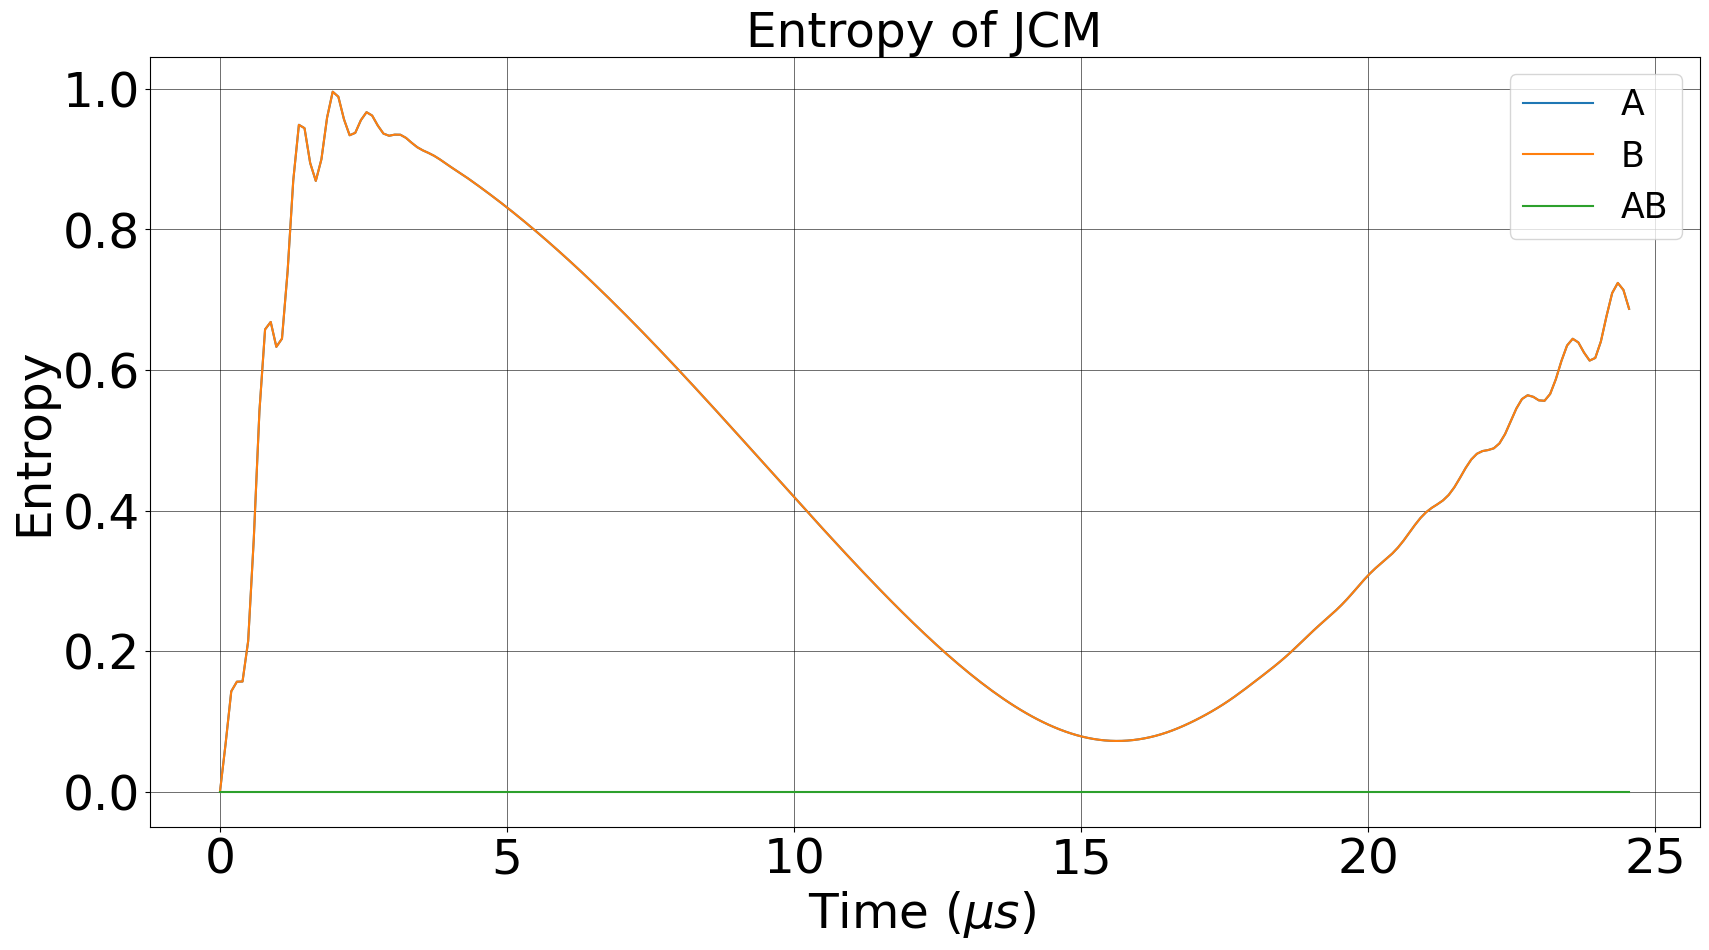

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, systemA_entropy, label='A')
axes.plot(tlist2, systemB_entropy, label='B')
axes.plot(tlist2, systemAB_entropy, label='AB')
axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
axes.set_ylabel("Entropy", fontsize = 35)
axes.set_title("Entropy of JCM", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [130]:
mutual_information = []
for i in range(len(tlist)):
    mutual_information.append(systemA_entropy[i] + systemB_entropy[i] - systemAB_entropy[i])

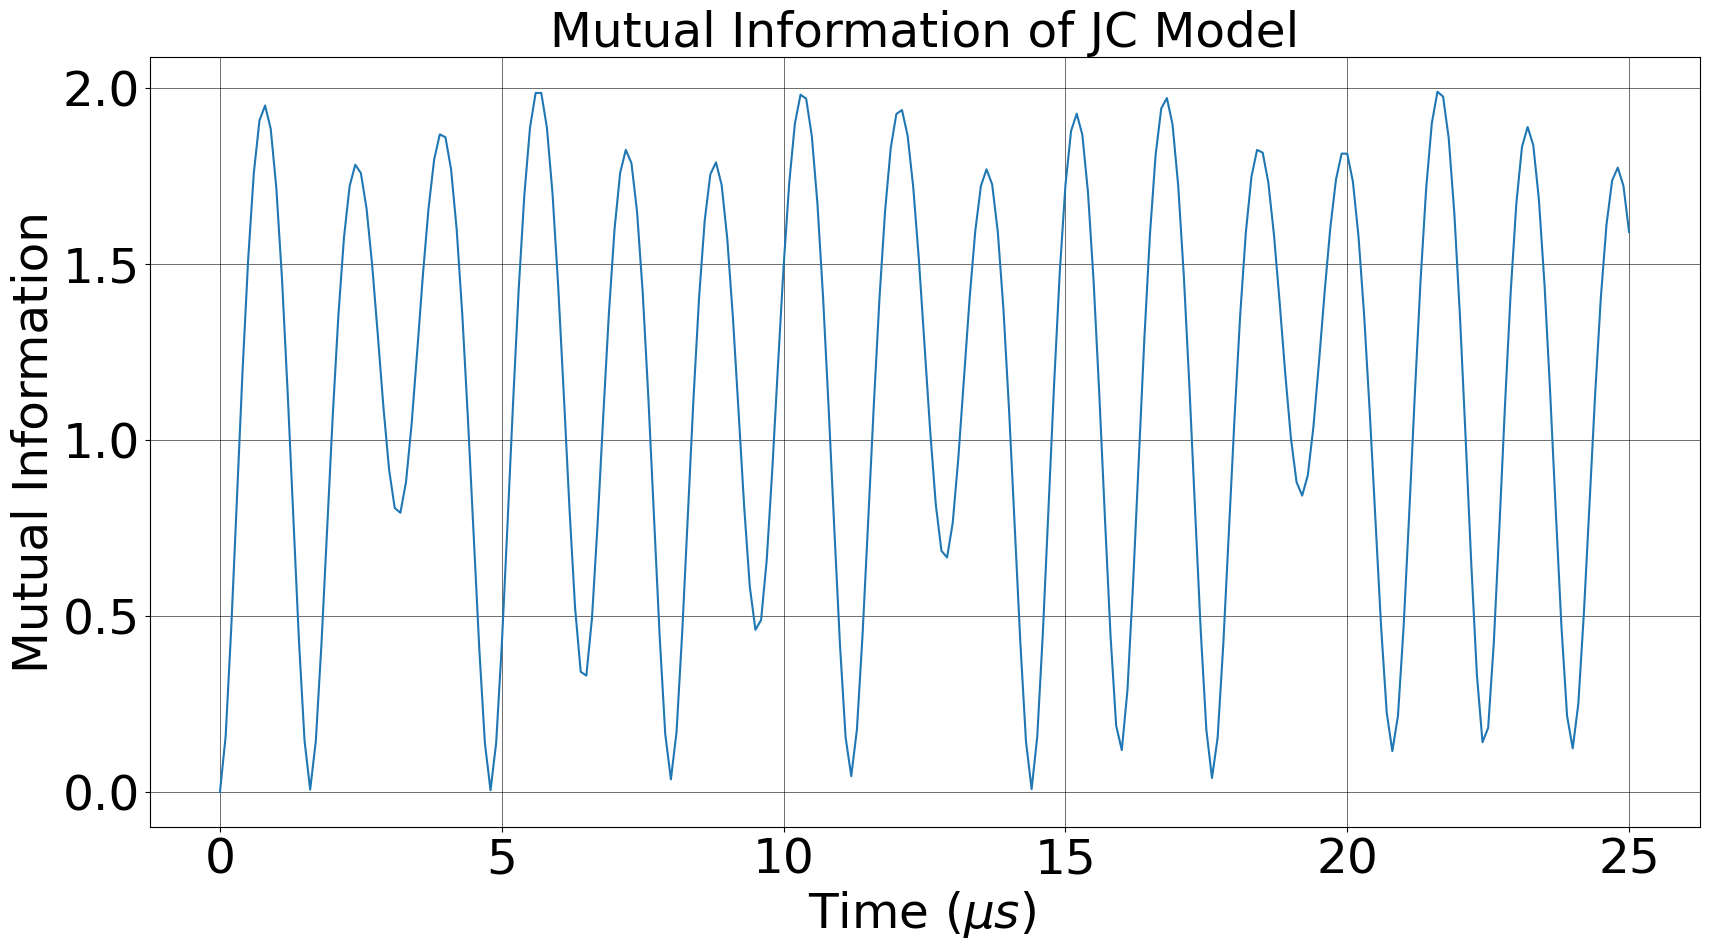

In [132]:
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,25,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, mutual_information)
#axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
axes.set_ylabel("Mutual Information", fontsize = 35)
axes.set_title("Mutual Information of JC Model", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,55)
plt.show()

In [ ]:
print(tlist2[102])

In [ ]:
def plot_wigner_3d(psi1,psi2,psi3):
    #fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
    fig = plt.figure(figsize=(17, 8))

    ax = fig.add_subplot(1, 3, 1, projection = '3d')
    plot_wigner(psi1, fig=fig, ax=ax, projection='3d')
    ax = fig.add_subplot(1, 3, 2, projection = '3d')
    plot_wigner(psi2, fig=fig, ax=ax, projection='3d')
    ax = fig.add_subplot(1, 3, 3, projection = '3d')
    plot_wigner(psi3, fig=fig, ax=ax, projection='3d')

    
    plt.close(fig)
    return fig

In [ ]:
plt.rc('xtick', labelsize=11)    
plt.rc('ytick', labelsize=11)
xvec = np.linspace(-5,5,200)

density_matrix1 = output.states[0] * output.states[0].dag()
reduced_density_matrix_B1 = density_matrix1.ptrace([1])
density_matrix2 = output.states[51] * output.states[51].dag()
reduced_density_matrix_B2 = density_matrix2.ptrace([1])
density_matrix3 = output.states[100] * output.states[100].dag()
reduced_density_matrix_B3 = density_matrix3.ptrace([1])


w_coherent1 = wigner(reduced_density_matrix_B1, xvec, xvec)
w_coherent2 = wigner(reduced_density_matrix_B2, xvec, xvec)
w_coherent3 = wigner(reduced_density_matrix_B3, xvec, xvec)

fig, axes = plt.subplots(1, 3, figsize=(12,3))

plt1 = cont0 = axes[0].contourf(xvec, xvec, w_coherent1, 100)
#lbl0 = axes[0].set_title(f'phi={phi:.2f}'r'$\lambda t = 0$')
lbl0 = axes[0].set_title(r'$\lambda t = 0$')
axes[0].set_xlabel('$<x>$', fontsize = 11)
#axes[0].set_ylabel('$<p>$', fontsize = 11)

plt2 = cont1 = axes[1].contourf(xvec, xvec, w_coherent2, 100)
lbl1 = axes[1].set_title(r'$\lambda t = 5$')
axes[1].set_xlabel('$<x>$', fontsize = 11)
#axes[1].set_ylabel('$<p>$', fontsize = 11)

plt3 = cont2 = axes[2].contourf(xvec, xvec, w_coherent3, 100)
lbl2 = axes[2].set_title(r'$\lambda t = 10$')
axes[2].set_xlabel('$<x>$', fontsize = 11)
#axes[2].set_ylabel('$<p>$', fontsize = 11)

cb1 = fig.colorbar(plt1, ax=axes[0])
cb2 = fig.colorbar(plt2, ax=axes[1])
cb3 = fig.colorbar(plt3, ax=axes[2])

#plt.subplots_adjust(wspace=0.5,top=0.7)
#plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4,hspace=0.4)

plt.show()

In [ ]:
psi1 = reduced_density_matrix_B1
psi2 = reduced_density_matrix_B2
psi3 = reduced_density_matrix_B3

plot_wigner_3d(psi1, psi2, psi3)
     
#plot_wigner_3d(reduced_density_matrix_B1, reduced_density_matrix_B2, reduced_density_matrix_B3)

In [ ]:
abcdefg = coherent(5,1)*coherent(5,1).dag()
print(np.trace(abcdefg.full()))

In [ ]:
test1 = coherent(5,1)*coherent(5,1).dag()*destroy(5).dag()*destroy(5)
#print(test1)
test2 = destroy(5).dag()*destroy(5)*coherent(5,1)*coherent(5,1).dag()
#print(test2)
#print(test1-test2)
#print(destroy(5).dag()*destroy(5))
#print(coherent(5,1)*coherent(5,1).dag())
print(np.trace((coherent(5,1)*coherent(5,1).dag()*destroy(5)).full()))
print(np.trace((destroy(5)*coherent(5,1)*coherent(5,1).dag()).full()))

In [ ]:
test3 = 1/2*(1/(2*(1+np.exp(-2*1**2)))*coherent(5,1)*coherent(5,1).dag()+1/(2*(1-np.exp(-2*1**2)))*coherent(5,1)*coherent(5,1).dag()+1/(2*(1+np.exp(-2*1**2)))*coherent(5,-1)*coherent(5,-1).dag()++1/(2*(1-np.exp(-2*1**2)))*coherent(5,-1)*coherent(5,-1).dag())

In [ ]:
print(np.trace(test3.full()))

In [ ]:
test4 = 1/2*(coherent(5,1)*coherent(5,1).dag()+coherent(5,-1)*coherent(5,-1).dag())

In [ ]:
print(np.trace(test4.full()))
print(test4)

In [ ]:
test5 = 1/2*(1/(2*(1+np.exp(-2*1**2)))*((coherent(5,1)+coherent(5,-1))*(coherent(5,1)+coherent(5,-1)).dag())
        +1/(2*(1-np.exp(-2*1**2)))*((coherent(5,1)-coherent(5,-1))*(coherent(5,1)-coherent(5,-1)).dag()))

In [ ]:
print(np.trace(test5.full()))
print(test5)